# Linear Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt

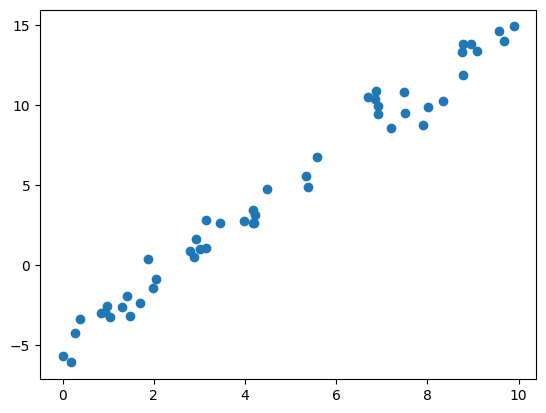

In [2]:
rng = np.random.RandomState(1)
x = 10 * rng.rand(50)
y = 2 * x - 5 + rng.randn(50)
plt.scatter(x, y);

In [4]:
from sklearn.linear_model import LinearRegression

R-squared: 0.9790800609430612
R-squared (sklearn): 0.9790800609430612


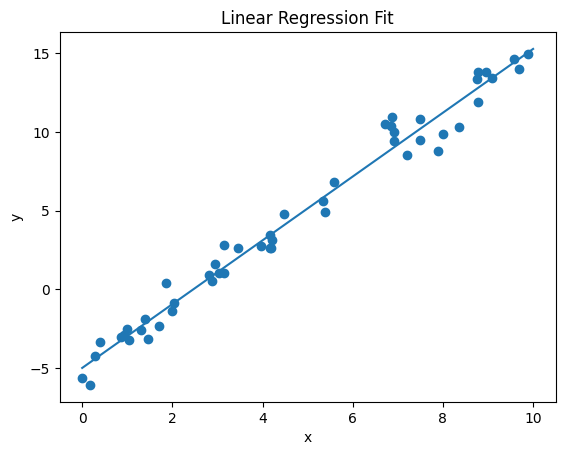

In [5]:
# Fit model
model = LinearRegression(fit_intercept=True)
model.fit(x[:, np.newaxis], y)

# Prediction on training data (IMPORTANT for R²)
y_pred = model.predict(x[:, np.newaxis])

# Smooth line for plotting
xfit = np.linspace(0, 10, 1000)
yfit = model.predict(xfit[:, np.newaxis])

# R² calculation
mean_y = np.mean(y)
tss = np.sum((y - mean_y)**2)
rss = np.sum((y - y_pred)**2)   # FIXED
r_squared = 1 - (rss / tss)

print("R-squared:", r_squared)

# Alternatively (recommended)
print("R-squared (sklearn):", model.score(x[:, np.newaxis], y))

# Plot
plt.scatter(x, y)
plt.plot(xfit, yfit)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.show()

In [ ]:
print("slope:    ", model.coef_[0])
print("intercept:", model.intercept_)

# k-mean clustering

In [6]:
np.random.seed(42)

# Create 3 clusters
cluster1 = np.random.randn(100, 2) + np.array([0, 0])
cluster2 = np.random.randn(100, 2) + np.array([5, 5])
cluster3 = np.random.randn(100, 2) + np.array([0, 5])

X = np.vstack((cluster1, cluster2, cluster3))


In [7]:
def kmeans(X, K=3, max_iters=10):

    # Randomly initialize centroids
    indices = np.random.choice(len(X), K, replace=False)
    centroids = X[indices]

    for iteration in range(max_iters):

        # Assignment Step
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # Plot current state
        plt.figure()
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.8)
        plt.scatter(centroids[:, 0], centroids[:, 1], s=200, marker='X')
        plt.title(f"Iteration {iteration+1}")
        plt.show()

        # Update Step
        new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(K)])
        diff=centroids-new_centroids


        # Stop if converged
        if np.allclose(centroids, new_centroids):
            print("Converged!")
            break

        centroids = new_centroids
        frobenius_distance = np.linalg.norm(diff)
        print(f"Frobenius Distance (scalar): {frobenius_distance}")

    return centroids, labels, diff


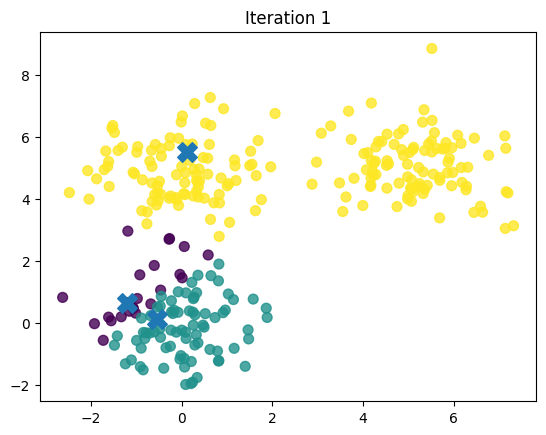

Frobenius Distance (scalar): 2.661179743909508


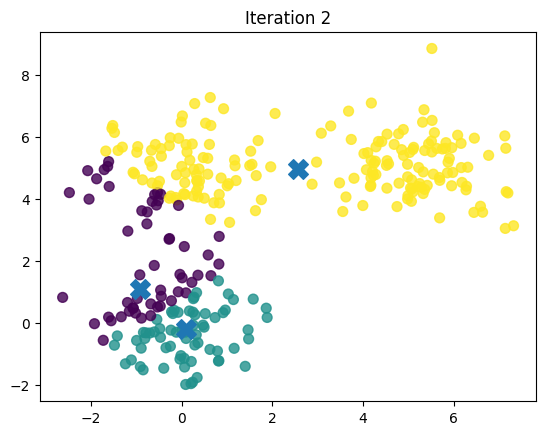

Frobenius Distance (scalar): 1.1395265890140172


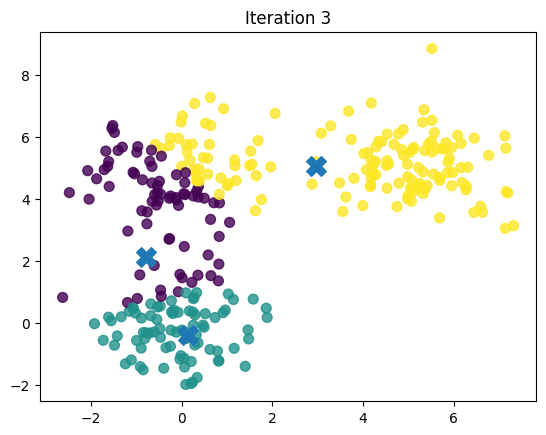

Frobenius Distance (scalar): 1.8573811641865516


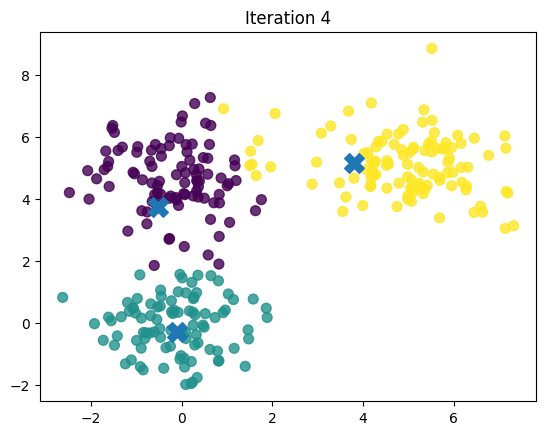

Frobenius Distance (scalar): 1.471243981231375


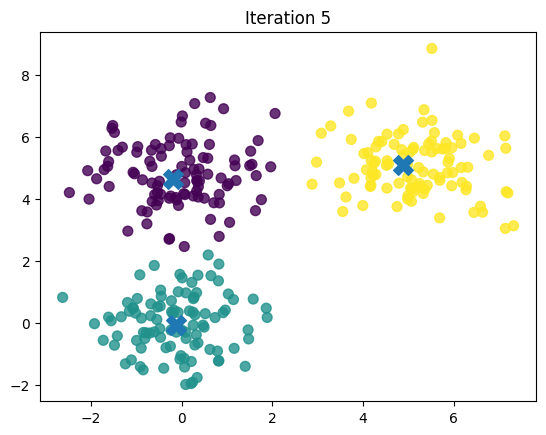

Frobenius Distance (scalar): 0.3388263111341156


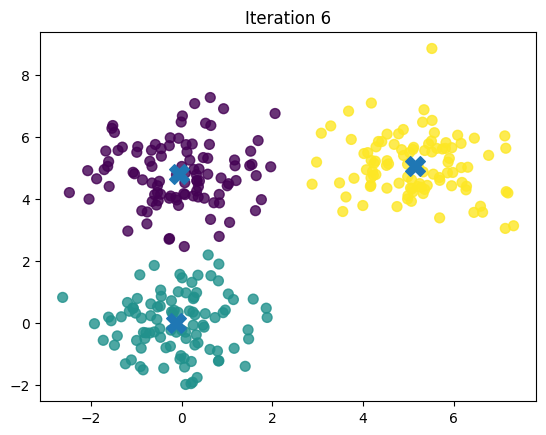

Converged!


In [8]:
centroids, labels, diff = kmeans(X, K=3, max_iters=10)


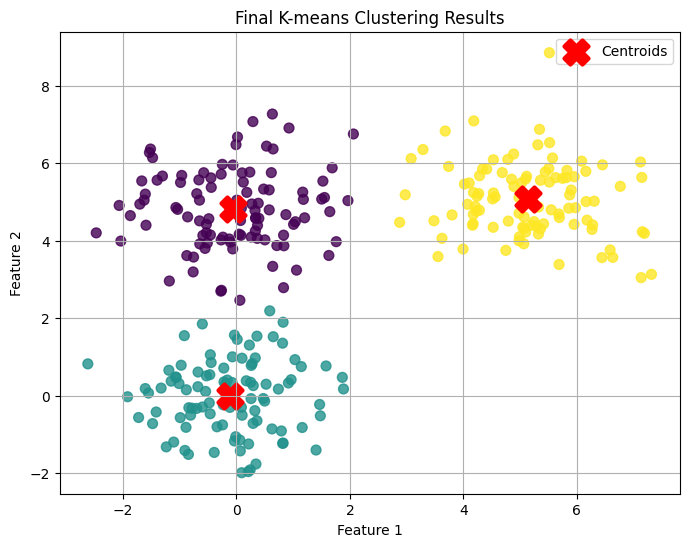

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.8)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=300, linewidths=3, color='red', label='Centroids')
plt.title('Final K-means Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

### **Principal Component Analysis**

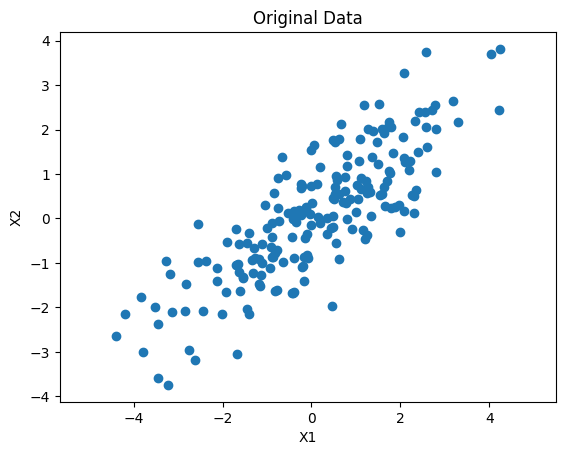

In [10]:
np.random.seed(0)

# Create correlated data
mean = [0, 0]
cov = [[3, 2],
       [2, 2]]

X = np.random.multivariate_normal(mean, cov, 200)

plt.figure()
plt.scatter(X[:,0], X[:,1])
plt.title("Original Data")
plt.xlabel("X1")
plt.ylabel("X2")
plt.axis("equal")
plt.show()


In [11]:
mu = np.mean(X, axis=0)
X_centered = X - mu

print("Mean:\n", mu)


Mean:
 [0.11516005 0.10244318]


In [12]:
Sigma = np.cov(X_centered.T)

print("Covariance Matrix:\n", Sigma)


Covariance Matrix:
 [[2.92525066 2.01507411]
 [2.01507411 2.04249278]]


In [13]:
eigvals, eigvecs = np.linalg.eig(Sigma)

# Sort eigenvalues descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print("Eigenvalues:\n", eigvals)
print("Eigenvectors:\n", eigvecs)


Eigenvalues:
 [4.54671903 0.42102441]
Eigenvectors:
 [[ 0.7790911  -0.62691073]
 [ 0.62691073  0.7790911 ]]


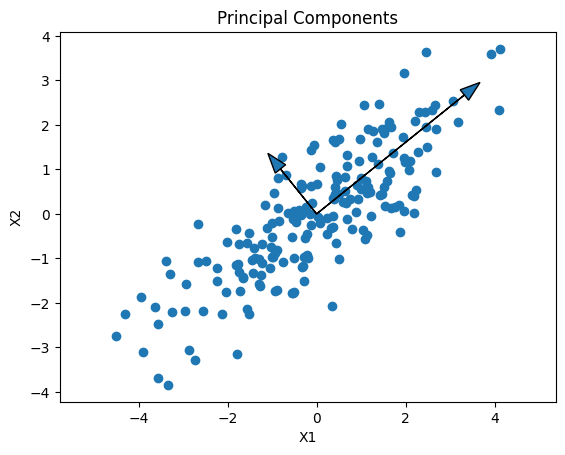

In [14]:
plt.figure()
plt.scatter(X_centered[:,0], X_centered[:,1])

# Plot eigenvectors
for i in range(2):
    vec = eigvecs[:, i]
    plt.arrow(0, 0,
              vec[0]*np.sqrt(eigvals[i])*2,
              vec[1]*np.sqrt(eigvals[i])*2,
              head_width=0.3)

plt.title("Principal Components")
plt.xlabel("X1")
plt.ylabel("X2")
plt.axis("equal")
plt.show()



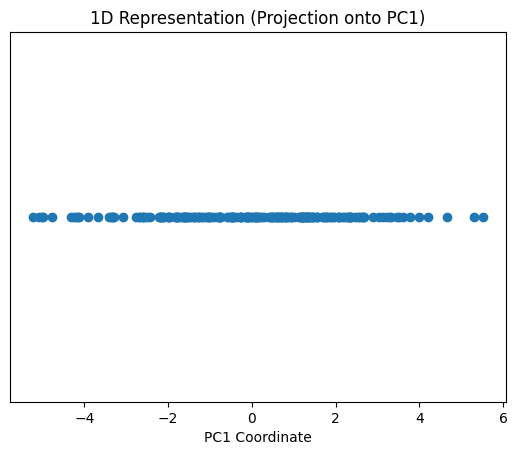

In [15]:
w1 = eigvecs[:, 0]   # First principal component

Z = X_centered @ w1   # Projection

plt.figure()
plt.scatter(Z, np.zeros_like(Z))
plt.yticks([])
plt.title("1D Representation (Projection onto PC1)")
plt.xlabel("PC1 Coordinate")
plt.show()


In [16]:
total_variance = np.sum(eigvals)
explained_variance_ratio = eigvals / total_variance

print("Explained Variance Ratio:", explained_variance_ratio)


Explained Variance Ratio: [0.91524836 0.08475164]


## **Linear Discriminant Analysis**

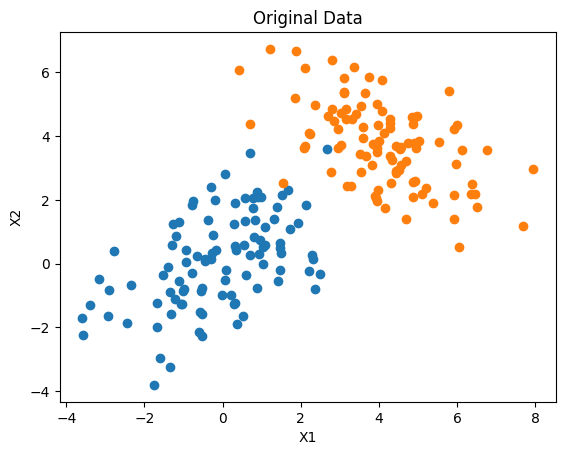

In [17]:
np.random.seed(0)

# Class 1
mean1 = [0, 0]
cov1 = [[2, 1],
        [1, 2]]
X1 = np.random.multivariate_normal(mean1, cov1, 100)

# Class 2
mean2 = [4, 4]
cov2 = [[2, -1],
        [-1, 2]]
X2 = np.random.multivariate_normal(mean2, cov2, 100)

X = np.vstack((X1, X2))
y = np.array([0]*100 + [1]*100)

plt.figure()
plt.scatter(X1[:,0], X1[:,1])
plt.scatter(X2[:,0], X2[:,1])
plt.title("Original Data")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()


In [18]:
mean1 = np.mean(X1, axis=0)
mean2 = np.mean(X2, axis=0)

overall_mean = np.mean(X, axis=0)

print("Class 1 Mean:", mean1)
print("Class 2 Mean:", mean2)



Class 1 Mean: [-0.09978685  0.10213268]
Class 2 Mean: [4.0953663  3.74489739]


compuate within class matrix

In [19]:
S1 = np.zeros((2,2))
for x in X1:
    diff = (x - mean1).reshape(2,1)
    S1 += diff @ diff.T

S2 = np.zeros((2,2))
for x in X2:
    diff = (x - mean2).reshape(2,1)
    S2 += diff @ diff.T

S_W = S1 + S2
print("Within-class Scatter Matrix:\n", S_W)


Within-class Scatter Matrix:
 [[399.33577669   8.28771919]
 [  8.28771919 380.80233538]]


compute between class matrix

In [20]:
diff1 = (mean1 - overall_mean).reshape(2,1)
diff2 = (mean2 - overall_mean).reshape(2,1)

S_B = diff1 @ diff1.T + diff2 @ diff2.T
print("Between-class Scatter Matrix:\n", S_B)


Between-class Scatter Matrix:
 [[8.79965496 7.64097791]
 [7.64097791 6.63486735]]


solve generalized eigenvalue problem

In [21]:
eigvals, eigvecs = np.linalg.eig(np.linalg.inv(S_W) @ S_B)

# Sort eigenvalues descending
idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, idx]

w = eigvecs[:, 0]   # Best discriminant direction
print("LDA Direction:\n", w)


LDA Direction:
 [0.74109948 0.67139523]


plot LDA directions

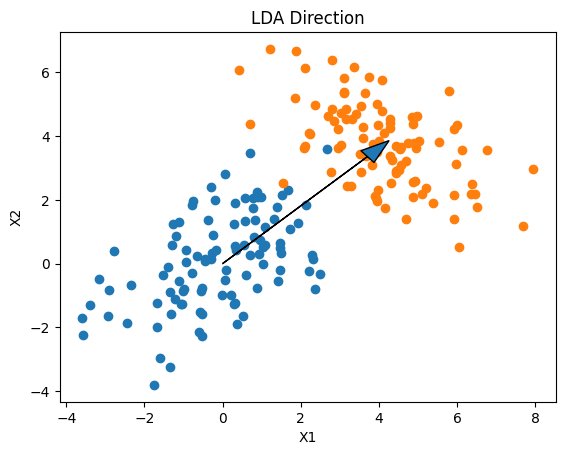

In [22]:
plt.figure()
plt.scatter(X1[:,0], X1[:,1])
plt.scatter(X2[:,0], X2[:,1])

plt.arrow(0, 0, w[0]*5, w[1]*5, head_width=0.5)

plt.title("LDA Direction")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()


Project data on 1D

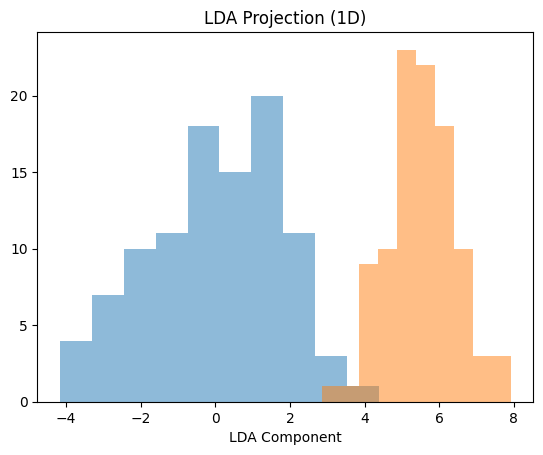

In [25]:
Z1 = X1 @ w
Z2 = X2 @ w

plt.figure()
plt.hist(Z1, alpha = 0.5)
plt.hist(Z2, alpha = 0.5)
plt.title("LDA Projection (1D)")
plt.xlabel("LDA Component")
plt.show()
